In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import nltk

In [2]:
df=pd.read_csv(r'D:\ProjectExhibition1\ProjectExb\Corona.csv')

In [3]:

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean text
def clean_text(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove special characters and numbers
        text = re.sub(r'[^A-Za-z\s]', '', text)
        # Lowercase the text
        text = text.lower()
        # Tokenize the text
        tokens = word_tokenize(text)
        # Remove stop words
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Lemmatize the tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        # Join the tokens back into a single string
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    except Exception as e:
        print(f"Error processing text: {text}\n{e}")
        return ''


# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)


In [4]:
from transformers import pipeline
from tqdm import tqdm  # Import tqdm for the progress bar

# Load the pre-trained emotion analysis model
emotion_classifier = pipeline('text-classification', model='j-hartmann/emotion-english-distilroberta-base')

# Define a function to classify emotions in the text
def classify_emotion(text):
    result = emotion_classifier(text)
    return result[0]['label']  # Get the emotion label

# Use tqdm to show the progress of text classification
tqdm.pandas()  # Enable tqdm for pandas progress_apply

# Apply the emotion classification function to the cleaned text with progress bar
df['emotion'] = df['cleaned_text'].progress_apply(classify_emotion)

# Display the first few rows to see the emotions
print(df[['cleaned_text', 'emotion']].head())


d:\ProjectExhibition1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu
100%|██████████| 34100/34100 [20:01<00:00, 28.39it/s]

                                        cleaned_text  emotion
0  one want study communist propaganda china viru...  neutral
1  chance create covid relief fund india many hap...      joy
2  fairness probably cant pronounce corona virus ...  neutral
3   bread left supermarket lot eat bread corona came  neutral
4  joke mean itmaybe start asking mothercousins a...  neutral


C:\Users\praph\AppData\Local\Temp\ipykernel_27664\3374948751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')


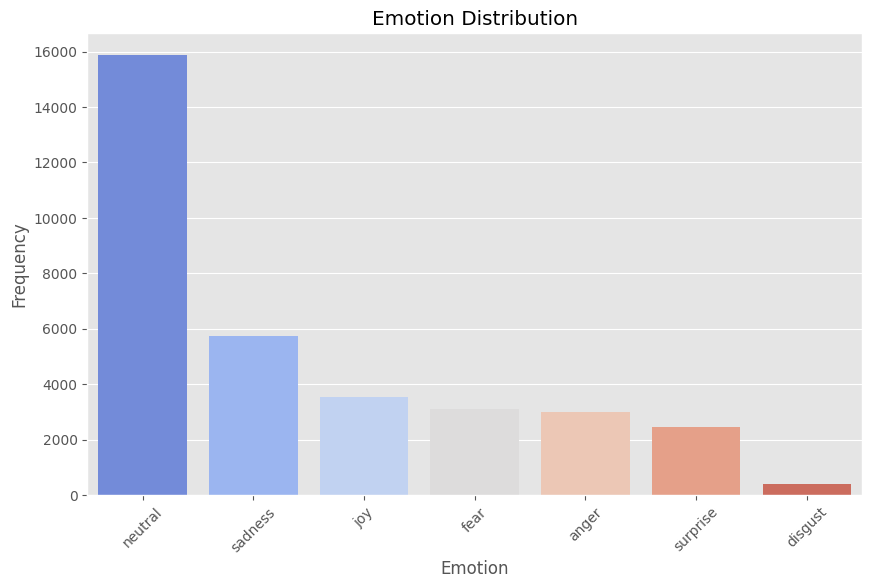

In [5]:
# Count the occurrences of each emotion
emotion_counts = df['emotion'].value_counts()

# Plot the distribution of emotions
plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

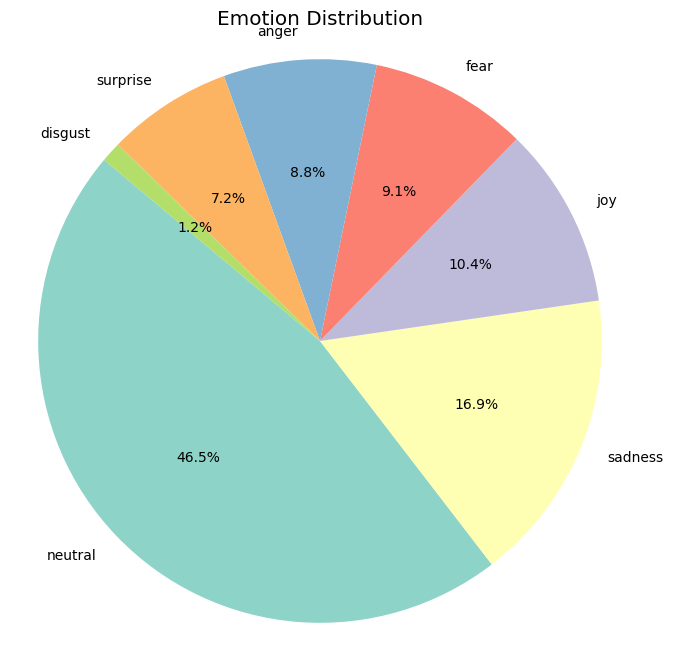

In [6]:
# Count the occurrences of each emotion
emotion_counts = df['emotion'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(emotion_counts)))

# Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.axis('equal')
plt.title('Emotion Distribution')

# Show the plot
plt.show()

C:\Users\praph\AppData\Local\Temp\ipykernel_27664\2529251336.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')


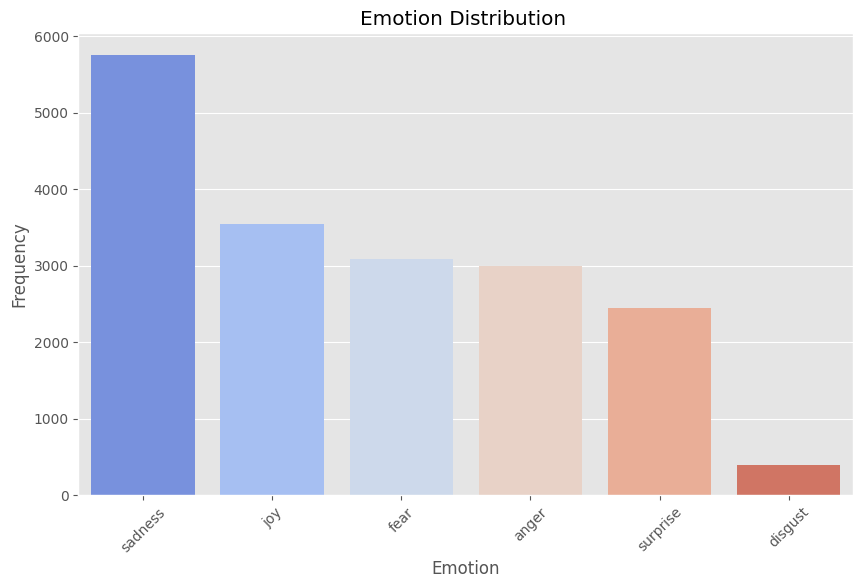

In [7]:
# Filter out 'neutral' emotion
filtered_df = df[df['emotion'] != 'neutral']

# Count the occurrences of each emotion (excluding neutral)
emotion_counts = filtered_df['emotion'].value_counts()

# Plot the distribution of emotions
plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')
plt.title('Emotion Distribution ')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()



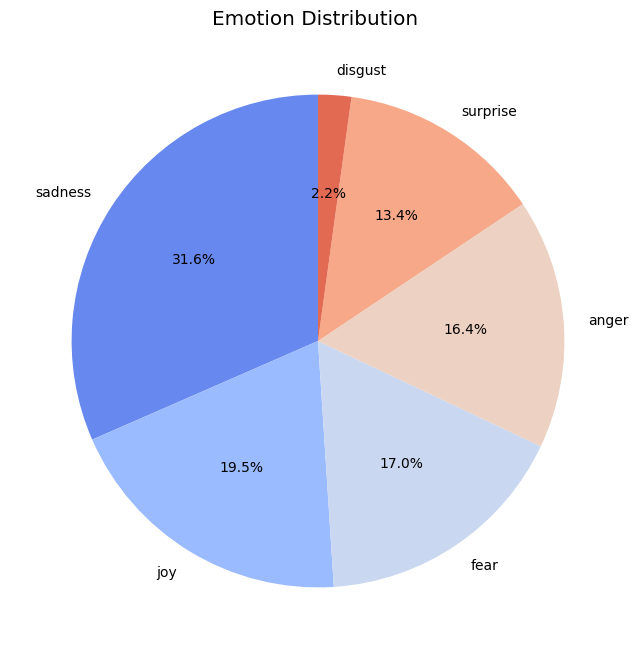

In [8]:
# Filter out 'neutral' emotion
filtered_df = df[df['emotion'] != 'neutral']

# Count the occurrences of each emotion (excluding neutral)
emotion_counts = filtered_df['emotion'].value_counts()

# Plot the distribution of emotions as a pie chart
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('coolwarm', len(emotion_counts)))
plt.title('Emotion Distribution ')
plt.show()